<a href="https://colab.research.google.com/github/Greeshma-babu/AI_Projects/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
from matplotlib import pyplot as plt
from textblob import TextBlob

review = [
        "This movie is amazing",
        "I love this product",
        "Worst experience ever",
        "Very bad service",
        "Excellent quality"
]

# print(review)
df = pd.DataFrame(review)
#print(df)
df["review"] = review
df.drop(columns=[0], inplace=True)
print(df)

                  review
0  This movie is amazing
1    I love this product
2  Worst experience ever
3       Very bad service
4      Excellent quality


                  review                                  sentiment  polarity  \
0  This movie is amazing                  (0.6000000000000001, 0.9)      0.60   
1    I love this product                                 (0.5, 0.6)      0.50   
2  Worst experience ever                                (-1.0, 1.0)     -1.00   
3       Very bad service  (-0.9099999999999998, 0.8666666666666667)     -0.91   
4      Excellent quality                                 (1.0, 1.0)      1.00   

   subjectivity  
0      0.900000  
1      0.600000  
2      1.000000  
3      0.866667  
4      1.000000  


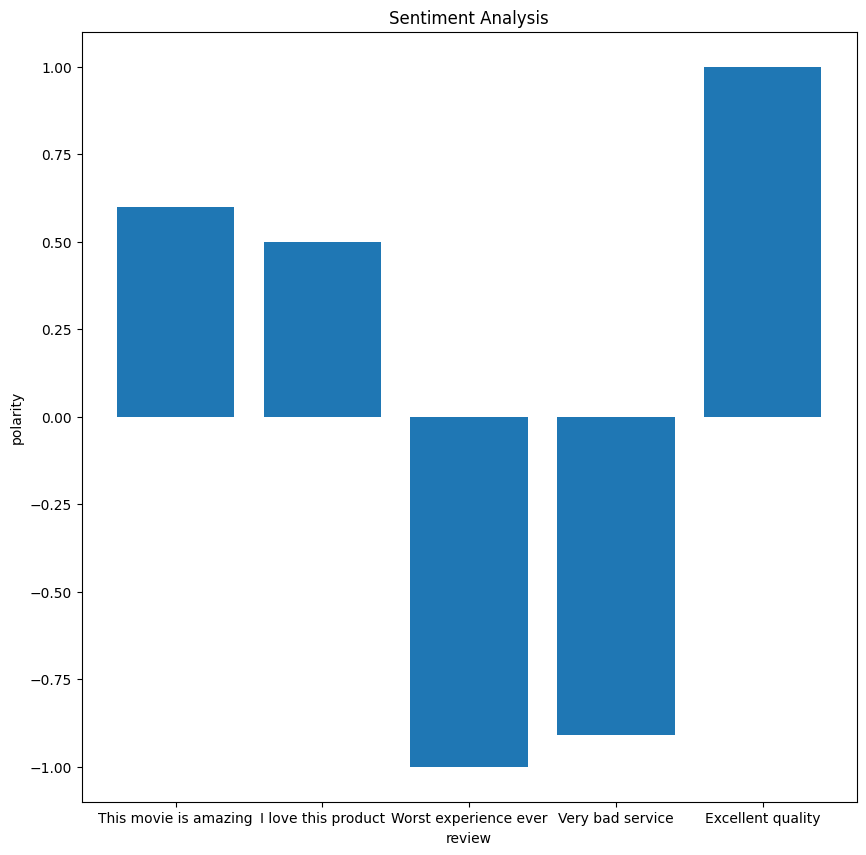

In [21]:
# Sentiment Analysis
def get_sentiment(text):
  return TextBlob(text).sentiment

df["sentiment"] = df["review"].apply(get_sentiment)
df["polarity"] = df["sentiment"].apply(lambda p: p.polarity)
df["subjectivity"] = df["sentiment"].apply(lambda s : s.subjectivity)
print(df)

plt.figure(figsize=(10,10))
plt.bar(df["review"], df["polarity"])
plt.title("Sentiment Analysis")
plt.xlabel("review")
plt.ylabel("polarity")
plt.show()

In [26]:
def get_emotion(p):
  if p > 0 :
      return "1"
  elif p < 0:
    return "-1"
  else :
    return "0"

df["emotion_value"] = df["polarity"].apply(get_emotion)
print(df)

                  review                                  sentiment  polarity  \
0  This movie is amazing                  (0.6000000000000001, 0.9)      0.60   
1    I love this product                                 (0.5, 0.6)      0.50   
2  Worst experience ever                                (-1.0, 1.0)     -1.00   
3       Very bad service  (-0.9099999999999998, 0.8666666666666667)     -0.91   
4      Excellent quality                                 (1.0, 1.0)      1.00   

   subjectivity   Emotion emotion_value  
0      0.900000  positive             1  
1      0.600000  positive             1  
2      1.000000  negative            -1  
3      0.866667  negative            -1  
4      1.000000  positive             1  


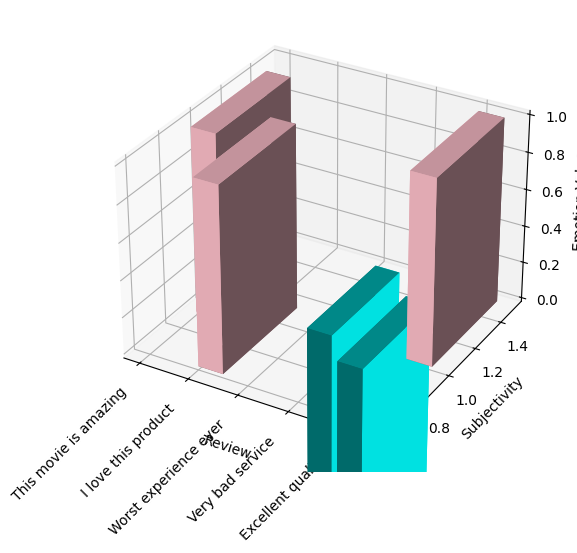

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.arange(len(df), dtype=float)
y = pd.to_numeric(df["subjectivity"], errors="coerce").values
z = np.zeros(len(df), dtype=float)

dx = np.full(len(df), 0.5)
dy = np.full(len(df), 0.5)
dz = pd.to_numeric(df["emotion_value"], errors="coerce").values

# Pink for positive, Cyan for negative
colors = ["pink" if val > 0 else "cyan" for val in dz]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(x, y, z, dx, dy, dz, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(df["review"], rotation=45, ha="right")

ax.set_xlabel("Review")
ax.set_ylabel("Subjectivity")
ax.set_zlabel("Emotion Value")

plt.show()